<a href="https://colab.research.google.com/github/shivasmi07/hurdle-health/blob/main/hurdle-health-trajectories.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# Files were uploaded straight into Colab (Files panel), so they live in /content
import os

DATA_DIR = "/content"                 # train.bin, val.bin, labels.csv
OUT_DIR = "/content/outputs"          # plots and processed data will be saved here
os.makedirs(OUT_DIR, exist_ok=True)

for f in ["train.bin", "val.bin", "labels.csv"]:
    print(f, "->", "found" if os.path.exists(os.path.join(DATA_DIR, f)) else "MISSING")

train.bin -> found
val.bin -> found
labels.csv -> found


In [27]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

pd.set_option("display.max_colwidth", 60)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e5e1",
    "grid.linewidth": 0.6,
})
BLUE, ORANGE = "#2a78d6", "#eb6834"


def save_fig(name):
    # save every figure to Drive so it can go in the report/slides
    plt.savefig(os.path.join(OUT_DIR, name), bbox_inches="tight", dpi=150)

In [28]:
# Line number in labels.csv = token index. 0 = Padding, 1 = Female, 2 = Male, 3+ = ICD-10 codes
with open(os.path.join(DATA_DIR, "labels.csv")) as f:
    names = [line.rstrip("\n") for line in f if line.strip() != ""]

vocab = pd.DataFrame({"token": range(len(names)), "name": names})
vocab["code"] = vocab["name"].str[:3]                        # e.g. "I10"
vocab["chapter"] = vocab["code"].str[0]                       # first letter = ICD-10 chapter
vocab.loc[vocab.token < 3, "chapter"] = "-"                   # padding / sex are not diagnoses
vocab.loc[vocab.token < 3, "code"] = vocab["name"]             # keep "Female"/"Male" readable

print("Vocabulary size:", len(vocab))
display(vocab.head(6))

Vocabulary size: 997


,token,name,code,chapter
0,0,Padding,Padding,-
1,1,Female,Female,-
2,2,Male,Male,-
3,3,A01 (typhoid and paratyphoid fevers),A01,A
4,4,A02 (other salmonella infections),A02,A
5,5,A03 (shigellosis),A03,A


In [29]:
# Each file is a flat list of uint32 numbers -> reshape to rows of (patient id, age in days, token)
# The stored token is (vocabulary index - 1), so we add 1 back.
def load_bin(split):
    raw = np.fromfile(os.path.join(DATA_DIR, f"{split}.bin"), dtype="<u4")
    arr = raw.reshape(-1, 3).astype(np.int64)
    df = pd.DataFrame(arr, columns=["pid", "age_days", "token"])
    df["token"] = df["token"] + 1
    df["age"] = df["age_days"] / 365.25                       # age in years
    df = df.merge(vocab[["token", "code", "name", "chapter"]], on="token", how="left")
    return df


train = load_bin("train")
test = load_bin("val")      # val.bin is used as our held-out TEST set

for split, df in [("train", train), ("test (val.bin)", test)]:
    print(f"{split:15s} {len(df):,} events | {df.pid.nunique():,} patients | age {df.age.min():.1f}-{df.age.max():.1f}")

train           179,390 events | 7,143 patients | age 0.0-80.0
test (val.bin)  179,423 events | 7,143 patients | age 0.0-80.0


In [30]:
# Look for diagnoses that can only happen in one sex, as evidence
male_only = ["C60", "C61", "C62", "C63", "N40", "N41", "N42", "N43", "N44", "N45", "N46", "N47", "N48", "N49", "N50", "N51"]
female_only = ["C51", "C52", "C53", "C54", "C55", "C56", "C57", "C58", "N70", "N71", "N72", "N73", "N80", "N81", "N83",
               "N84", "N85", "N86", "N87", "N88", "N89", "N90", "N91", "N92", "N93", "N94", "N95", "N97"] + \
              [c for c in vocab.code if str(c).startswith("O")]          # pregnancy codes

for pid in no_sex:
    history = train[train.pid == pid]
    print(f"Patient {pid}:")
    print("  male-only diagnoses:  ", history[history.code.isin(male_only)][["code", "name", "age"]].round(1).values.tolist())
    print("  female-only diagnoses:", history[history.code.isin(female_only)][["code", "name", "age"]].round(1).values.tolist())

# Prostate cancer (C61) is male-only, so we record this patient as Male at age 0.
# Caveat (worth mentioning): the evidence comes from a diagnosis at 65, so this uses
# later information to fill in something that is known at birth. It affects 1 of 7,143 patients.
new_rows = []
for pid in no_sex:
    row = train[train.pid == pid].iloc[[0]].copy()
    row[["age_days", "token", "age"]] = [0, 2, 0.0]                  # token 2 = Male
    row[["code", "name", "chapter"]] = ["Male", "Male", "-"]
    new_rows.append(row)

# add the new rows, then put every patient's events back in time order (sex first)
patient_order = {pid: i for i, pid in enumerate(train.pid.unique())}
train = pd.concat([train] + new_rows, ignore_index=True)
train["_order"] = train.pid.map(patient_order)
train["_is_dx"] = (train.token >= 3).astype(int)
train = train.sort_values(["_order", "age_days", "_is_dx"], kind="stable").drop(columns=["_order", "_is_dx"]).reset_index(drop=True)

# check the fix worked
print("\nPatients with no sex token now:", train.pid.nunique() - train[train.token.isin([1, 2])].pid.nunique())
display(train[train.pid == 402867][["pid", "age", "code", "name"]].round(1).head(5))

Patient 402867:
  male-only diagnoses:   [['C61', 'C61 Malignant neoplasm of prostate', 65.2]]
  female-only diagnoses: []

Patients with no sex token now: 0


,pid,age,code,name
0,402867,0.0,Male,Male
1,402867,3.4,J45,J45 (asthma)
2,402867,24.3,L30,L30 (other dermatitis)
3,402867,42.5,L20,L20 (atopic dermatitis)
4,402867,58.7,I10,I10 (essential (primary) hypertension)


In [31]:
#look at one patient

example = train[train.pid == 402868][["pid", "age", "code", "name"]]
display(example.round(1).head(15))

,pid,age,code,name
27,402868,0.0,Female,Female
28,402868,30.6,O80,O80 (single spontaneous delivery)
29,402868,38.1,M54,M54 (dorsalgia)
30,402868,39.1,F34,F34 (persistent mood [affective] disorders)
31,402868,40.6,M51,M51 (other intervertebral disk disorders)
32,402868,44.6,M77,M77 (other enthesopathies)
33,402868,46.6,N84,N84 (polyp of female genital tract)
34,402868,48.9,K64,K64 (haemorrhoids and perianal venous thrombosis)
35,402868,48.9,J11,"J11 (influenza, virus not identified)"
36,402868,49.1,M25,"M25 (other joint disorders, not elsewhere classified)"


In [32]:
#EDA
def sanity_checks(df):
    dx = df[df.token >= 3]                       # diagnoses only
    sex = df[df.token.isin([1, 2])]              # sex tokens only
    by_patient = df.groupby("pid", sort=False)
    return {
        "events": len(df),
        "patients": df.pid.nunique(),
        "padding tokens (should be 0)": int((df.token == 0).sum()),
        "unknown tokens (should be 0)": int((df.token >= len(vocab)).sum()),
        "ages sorted within each patient": bool((by_patient.age_days.diff().dropna() >= 0).all()),
        "patients with no sex token": df.pid.nunique() - sex.pid.nunique(),
        "sex token not at age 0": int((sex.age_days != 0).sum()),
        "duplicate rows": int(df.duplicated(["pid", "age_days", "token"]).sum()),
        "same diagnosis twice in a patient": int(dx.duplicated(["pid", "token"]).sum()),
        "% diagnoses on same day as another": round(100 * dx.duplicated(["pid", "age_days"], keep=False).mean(), 2),
    }


checks = pd.DataFrame({"train": sanity_checks(train), "test": sanity_checks(test)})
display(checks)

# Leakage check: no patient should be in both files
overlap = set(train.pid) & set(test.pid)
print("Patients in both train and test:", len(overlap))

# Which patient has no sex token?
no_sex = set(train.pid) - set(train.loc[train.token.isin([1, 2]), "pid"])
print("Train patient(s) with no sex token:", no_sex)

,train,test
events,179391,179423
patients,7143,7143
padding tokens (should be 0),0,0
unknown tokens (should be 0),0,0
ages sorted within each patient,True,True
patients with no sex token,0,0
sex token not at age 0,0,0
duplicate rows,0,0
same diagnosis twice in a patient,0,0
% diagnoses on same day as another,0.26,0.28


Patients in both train and test: 0
Train patient(s) with no sex token: set()


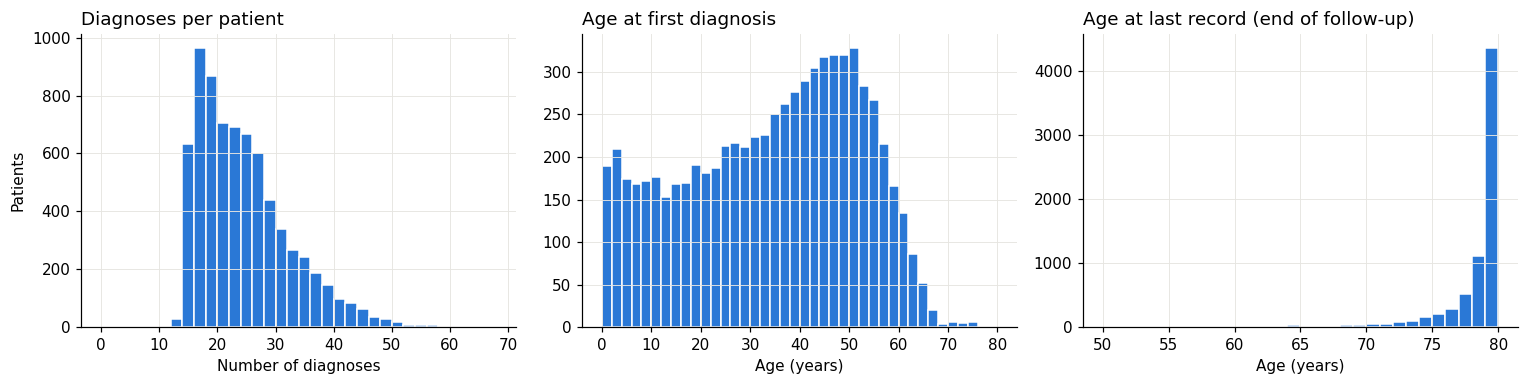

Median diagnoses per patient: 23
Patients whose record ends before age 75: 9.2%  (died or left the records - we can't tell which)


In [33]:
#Plot 1, patient histories
def patient_summary(df):
    dx = df[df.token >= 3]
    out = pd.DataFrame({
        "n_dx": dx.groupby("pid").size(),
        "first_dx_age": dx.groupby("pid").age.min(),
        "last_age": df.groupby("pid").age.max(),
    })
    sex = df[df.token.isin([1, 2])].set_index("pid").token.map({1: "Female", 2: "Male"})
    out["sex"] = sex.reindex(out.index).fillna("Unknown")
    return out


pt_train = patient_summary(train)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

axes[0].hist(pt_train.n_dx, bins=range(0, 70, 2), color=BLUE, edgecolor="white")
axes[0].set_title("Diagnoses per patient", loc="left")
axes[0].set_xlabel("Number of diagnoses")
axes[0].set_ylabel("Patients")

axes[1].hist(pt_train.first_dx_age, bins=range(0, 81, 2), color=BLUE, edgecolor="white")
axes[1].set_title("Age at first diagnosis", loc="left")
axes[1].set_xlabel("Age (years)")

axes[2].hist(pt_train.last_age, bins=range(50, 81, 1), color=BLUE, edgecolor="white")
axes[2].set_title("Age at last record (end of follow-up)", loc="left")
axes[2].set_xlabel("Age (years)")

plt.tight_layout()
save_fig("eda_1_patient_histories.png")
plt.show()

print(f"Median diagnoses per patient: {pt_train.n_dx.median():.0f}")
print(f"Patients whose record ends before age 75: {100 * (pt_train.last_age < 75).mean():.1f}%  "
      "(died or left the records - we can't tell which)")

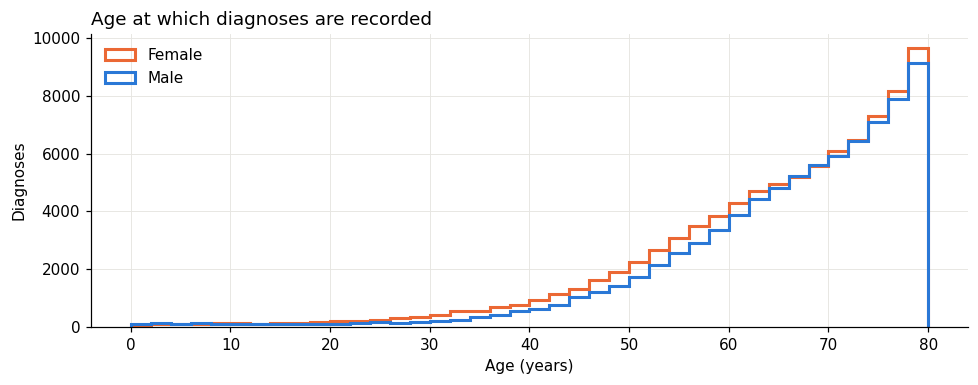

Diagnoses recorded after age 60: 71%


In [34]:
#Plot 2, age at diagnosis by sex
dx_train = train[train.token >= 3]

fig, ax = plt.subplots(figsize=(9, 3.6))
for sex_token, label, colour in [(1, "Female", ORANGE), (2, "Male", BLUE)]:
    pids = train.loc[train.token == sex_token, "pid"]
    ages = dx_train.loc[dx_train.pid.isin(pids), "age"]
    ax.hist(ages, bins=range(0, 81, 2), histtype="step", linewidth=2, color=colour, label=label)
ax.set_title("Age at which diagnoses are recorded", loc="left")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Diagnoses")
ax.legend(frameon=False)
plt.tight_layout()
save_fig("eda_2_age_of_diagnoses.png")
plt.show()

print(f"Diagnoses recorded after age 60: {100 * (dx_train.age >= 60).mean():.0f}%")

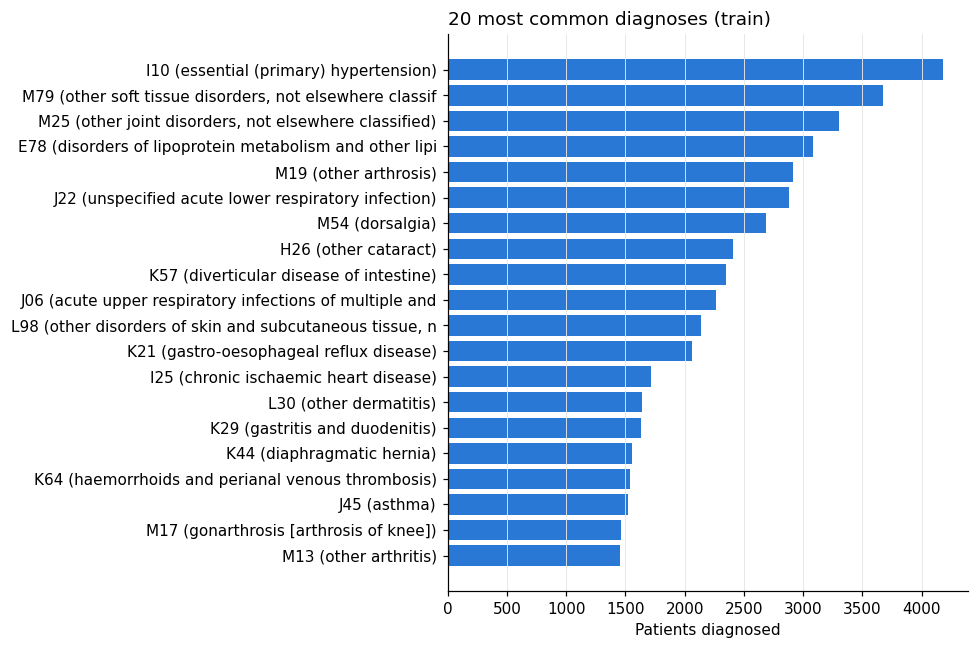

Different codes used: 929 | codes used fewer than 5 times: 192


In [35]:
#Plot 3, top 20 diagnoses
top20 = dx_train["name"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh([n[:55] for n in top20.index[::-1]], top20.values[::-1], color=BLUE)
ax.set_title("20 most common diagnoses (train)", loc="left")
ax.set_xlabel("Patients diagnosed")
ax.grid(axis="y", visible=False)
plt.tight_layout()
save_fig("eda_3_top_diagnoses.png")
plt.show()

counts = dx_train.token.value_counts()
print(f"Different codes used: {len(counts)} | codes used fewer than 5 times: {(counts < 5).sum()}")


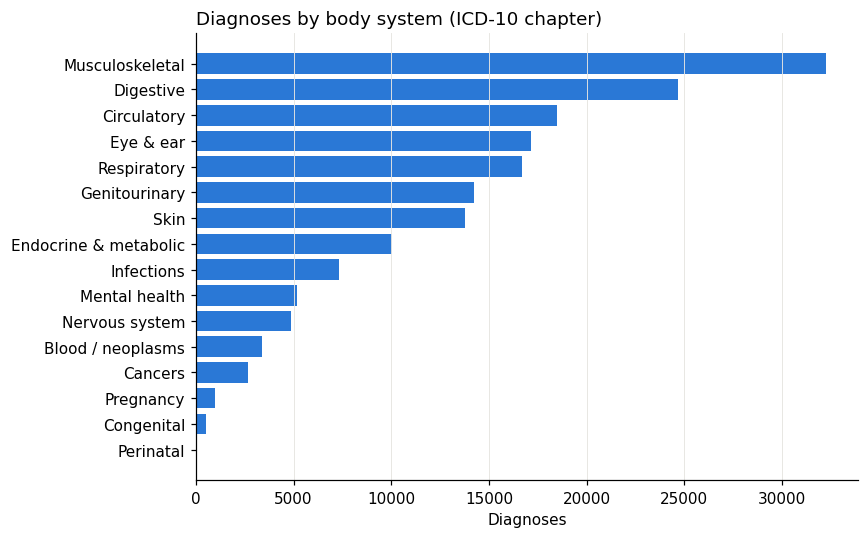

In [36]:
#Plot 4, diagnoses by body system
chapter_names = {
    "A": "Infections", "B": "Infections", "C": "Cancers", "D": "Blood / neoplasms", "E": "Endocrine & metabolic",
    "F": "Mental health", "G": "Nervous system", "H": "Eye & ear", "I": "Circulatory", "J": "Respiratory",
    "K": "Digestive", "L": "Skin", "M": "Musculoskeletal", "N": "Genitourinary", "O": "Pregnancy",
    "P": "Perinatal", "Q": "Congenital",
}
by_chapter = dx_train.chapter.map(chapter_names).value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(by_chapter.index, by_chapter.values, color=BLUE)
ax.set_title("Diagnoses by body system (ICD-10 chapter)", loc="left")
ax.set_xlabel("Diagnoses")
ax.grid(axis="y", visible=False)
plt.tight_layout()
save_fig("eda_4_chapters.png")
plt.show()

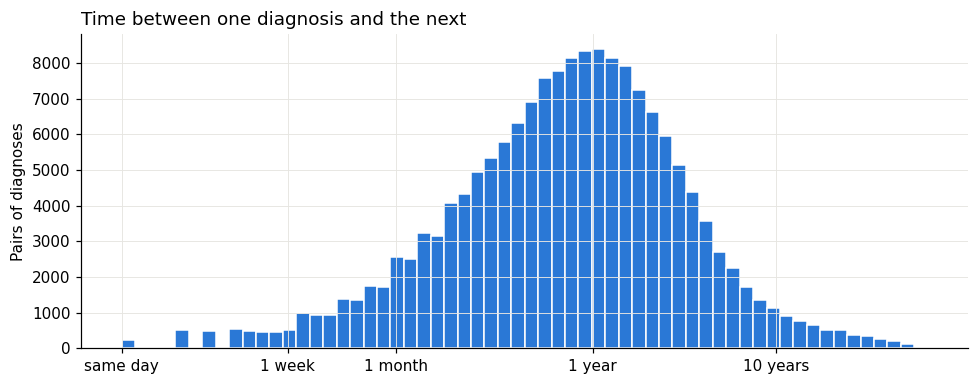

Median gap: 0.8 years | within 1 year: 57% | over 10 years: 3%


In [37]:
#Plot 5, time gaps between diagnoses
# Irregular gaps are why we give the model the AGE of each event, not just the order.
gaps = dx_train.groupby("pid").age.diff().dropna()

fig, ax = plt.subplots(figsize=(9, 3.6))
gap_days = gaps * 365.25
ax.hist(np.log1p(gap_days), bins=60, color=BLUE, edgecolor="white")     # log scale: days to decades
ax.set_xticks(np.log1p([0, 7, 30, 365, 3650]))
ax.set_xticklabels(["same day", "1 week", "1 month", "1 year", "10 years"])
ax.set_title("Time between one diagnosis and the next", loc="left")
ax.set_ylabel("Pairs of diagnoses")
plt.tight_layout()
save_fig("eda_5_gaps.png")
plt.show()

print(f"Median gap: {gaps.median():.1f} years | within 1 year: {100 * (gaps < 1).mean():.0f}% | over 10 years: {100 * (gaps > 10).mean():.0f}%")

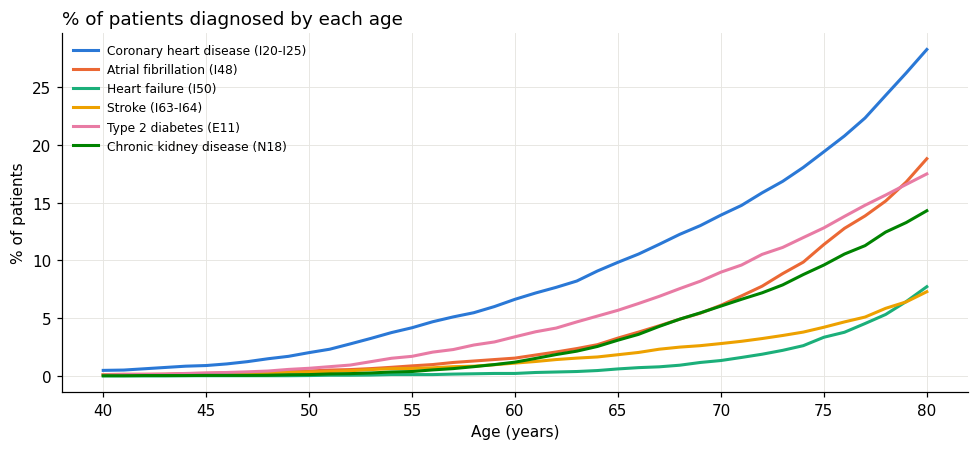

In [38]:
#Plot 6, key clinical conditions by age
# These are the conditions we will report results on later (clinical lens).
key_conditions = {
    "Coronary heart disease (I20-I25)": ["I20", "I21", "I22", "I23", "I24", "I25"],
    "Atrial fibrillation (I48)": ["I48"],
    "Heart failure (I50)": ["I50"],
    "Stroke (I63-I64)": ["I63", "I64"],
    "Type 2 diabetes (E11)": ["E11"],
    "Chronic kidney disease (N18)": ["N18"],
}
n_patients = train.pid.nunique()
colours = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
age_grid = np.arange(40, 81)

fig, ax = plt.subplots(figsize=(9, 4.2))
for (label, codes), colour in zip(key_conditions.items(), colours):
    first_age = dx_train[dx_train.code.isin(codes)].groupby("pid").age.min()
    pct = [100 * (first_age <= a).sum() / n_patients for a in age_grid]
    ax.plot(age_grid, pct, linewidth=2, color=colour, label=label)
ax.set_title("% of patients diagnosed by each age", loc="left")
ax.set_xlabel("Age (years)")
ax.set_ylabel("% of patients")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
save_fig("eda_6_key_conditions.png")
plt.show()
# Note: this slightly underestimates risk at older ages, because ~10% of records end before 75.

Preprocessing

In [39]:
#split train into fit and tune
# Task: at every point in a patient's history, predict their NEXT diagnosis.
# FIT  = used to train the models
# TUNE = used to choose settings / early stopping (so we never peek at the test set)
# TEST = val.bin, only used once at the very end
rng = np.random.default_rng(seed=0)
train_pids = np.array(sorted(train.pid.unique()))
rng.shuffle(train_pids)

n_tune = int(0.1 * len(train_pids))
tune_pids = set(train_pids[:n_tune])
fit_pids = set(train_pids[n_tune:])

print(f"Fit: {len(fit_pids)} patients | Tune: {len(tune_pids)} patients | Test: {test.pid.nunique()} patients")

Fit: 6429 patients | Tune: 714 patients | Test: 7143 patients


In [40]:
#build patient sequences
# Each patient becomes [sex, dx1, dx2, ...] with matching ages
SEX_UNKNOWN = len(vocab)        # new token 997 for the one patient with no sex record
UNK = len(vocab) + 1            # new token 998 for codes never seen in the fit set
N_TOKENS = len(vocab) + 2


def build_sequences(df, pids):
    sequences = {}
    for pid, g in df[df.pid.isin(pids)].groupby("pid", sort=False):
        sex = g[g.token.isin([1, 2])]
        dx = g[g.token >= 3]
        sex_token = int(sex.token.iloc[0]) if len(sex) > 0 else SEX_UNKNOWN
        tokens = [sex_token] + dx.token.tolist()
        ages = [0.0] + dx.age.tolist()
        sequences[pid] = (np.array(tokens), np.array(ages))
    return sequences


seqs = {
    "fit": build_sequences(train, fit_pids),
    "tune": build_sequences(train, tune_pids),
    "test": build_sequences(test, set(test.pid)),
}
for split, s in seqs.items():
    print(f"{split:5s}: {len(s)} patient sequences")

fit  : 6429 patient sequences
tune : 714 patient sequences
test : 7143 patient sequences


In [41]:
# A code the model never saw in training would have an untrained embedding,
# so in tune/test inputs it is replaced by UNK. (Targets keep their real code.)
known_codes = set()
for tokens, _ in seqs["fit"].values():
    known_codes.update(t for t in tokens if t >= 3 and t < len(vocab))


def input_tokens(tokens):
    # replace diagnosis codes not in known_codes with UNK
    return np.array([t if (t < 3 or t >= len(vocab) or t in known_codes) else UNK for t in tokens])


print("Diagnosis codes in the fit vocabulary:", len(known_codes))
for split in ["tune", "test"]:
    n_unk = sum((input_tokens(t) == UNK).sum() for t, _ in seqs[split].values())
    print(f"UNK tokens in {split}: {n_unk}")

Diagnosis codes in the fit vocabulary: 921
UNK tokens in tune: 12
UNK tokens in test: 108


In [42]:
# Every diagnosis becomes one example: (history so far) -> (next diagnosis).
# The history is everything recorded strictly BEFORE that diagnosis' day
# (so same-day diagnoses are not used to predict each other).
def make_examples(sequences):
    rows = []
    for pid, (tokens, ages) in sequences.items():
        for j in range(1, len(tokens)):                   # position 0 is sex, not a target
            history_len = int(np.searchsorted(ages, ages[j], side="left"))
            history_len = max(history_len, 1)             # always keep the sex token
            rows.append({
                "pid": pid,
                "history_len": history_len,               # how many tokens the model sees
                "target": int(tokens[j]),                 # the next diagnosis
                "current_age": ages[history_len - 1],     # age at the latest visible event
                "target_age": ages[j],                    # kept for checks only, NOT a model input
            })
    return pd.DataFrame(rows)


examples = {split: make_examples(s) for split, s in seqs.items()}
for split, ex in examples.items():
    print(f"{split:5s}: {len(ex):,} prediction examples")

fit  : 155,303 prediction examples
tune : 16,945 prediction examples
test : 172,280 prediction examples


In [43]:
#what one patient turns into
code_of = dict(zip(vocab.token, vocab.code))
code_of.update({1: "Female", 2: "Male", SEX_UNKNOWN: "SEX?", UNK: "UNK"})

pid = 402868
tokens, ages = seqs["fit"][pid]
ex = examples["fit"][examples["fit"].pid == pid].head(6).copy()
ex["model sees"] = ex.history_len.apply(lambda n: " -> ".join(code_of[t] for t in tokens[:n]))
ex["next diagnosis"] = ex.target.map(code_of)
display(ex[["model sees", "current_age", "next diagnosis"]].round(1))

,model sees,current_age,next diagnosis
26,Female,0.0,O80
27,Female -> O80,30.6,M54
28,Female -> O80 -> M54,38.1,F34
29,Female -> O80 -> M54 -> F34,39.1,M51
30,Female -> O80 -> M54 -> F34 -> M51,40.6,M77
31,Female -> O80 -> M54 -> F34 -> M51 -> M77,44.6,N84


In [44]:
#leakage checks (stops with an error if anything is wrong)
assert not (fit_pids & tune_pids), "patient in both fit and tune"
assert not (fit_pids & set(test.pid)), "patient in both fit and test"
assert not (tune_pids & set(test.pid)), "patient in both tune and test"

for split in ["fit", "tune", "test"]:
    for row in examples[split].itertuples():
        tokens, ages = seqs[split][row.pid]
        history_tokens = tokens[:row.history_len]
        history_ages = ages[:row.history_len]
        # 1. everything in the history happened strictly before the target
        assert row.history_len == 1 or history_ages[-1] < row.target_age
        # 2. the answer is never inside its own history
        assert row.target not in history_tokens
    print(f"{split:5s}: leakage checks passed")

missing = (~examples["test"].target.isin(known_codes)).sum()
print(f"\nTest targets with a code never seen in fit: {missing} -> can't be predicted, counted as misses")

fit  : leakage checks passed
tune : leakage checks passed
test : leakage checks passed

Test targets with a code never seen in fit: 108 -> can't be predicted, counted as misses


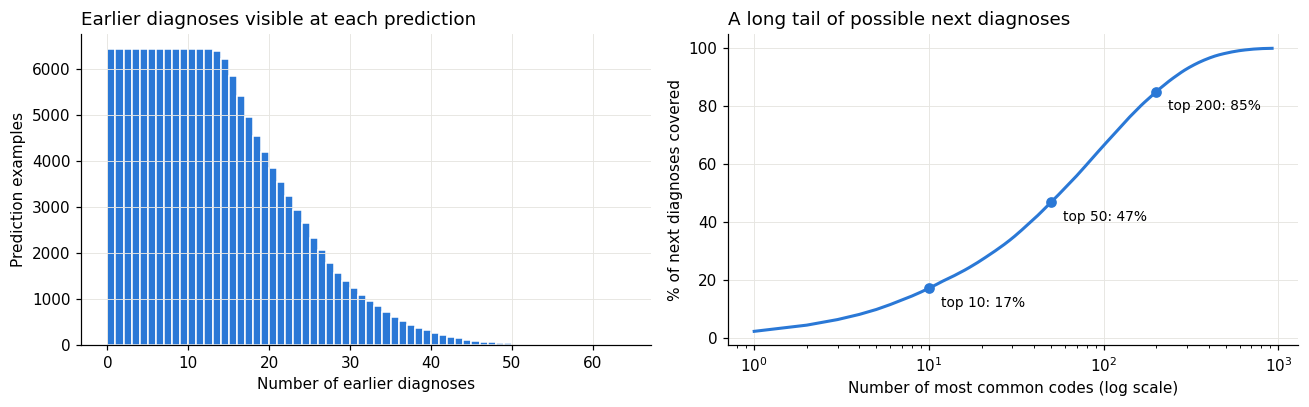

Always guessing the most common code (I10) would be right 2.4% of the time.


In [45]:
#Plot 7, history length and the long tail
fit_ex = examples["fit"]
target_counts = fit_ex.target.value_counts()
coverage = 100 * target_counts.cumsum() / target_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

axes[0].hist(fit_ex.history_len - 1, bins=range(0, 65), color=BLUE, edgecolor="white")
axes[0].set_title("Earlier diagnoses visible at each prediction", loc="left")
axes[0].set_xlabel("Number of earlier diagnoses")
axes[0].set_ylabel("Prediction examples")

axes[1].plot(range(1, len(coverage) + 1), coverage.values, color=BLUE, linewidth=2)
for k in [10, 50, 200]:
    axes[1].scatter(k, coverage.iloc[k - 1], color=BLUE, zorder=3)
    axes[1].annotate(f"top {k}: {coverage.iloc[k - 1]:.0f}%", (k, coverage.iloc[k - 1]),
                     xytext=(8, -12), textcoords="offset points", fontsize=9)
axes[1].set_xscale("log")
axes[1].set_title("A long tail of possible next diagnoses", loc="left")
axes[1].set_xlabel("Number of most common codes (log scale)")
axes[1].set_ylabel("% of next diagnoses covered")

plt.tight_layout()
save_fig("prep_1_history_and_long_tail.png")
plt.show()

print(f"Always guessing the most common code ({code_of[target_counts.index[0]]}) "
      f"would be right {100 * target_counts.iloc[0] / len(fit_ex):.1f}% of the time.")

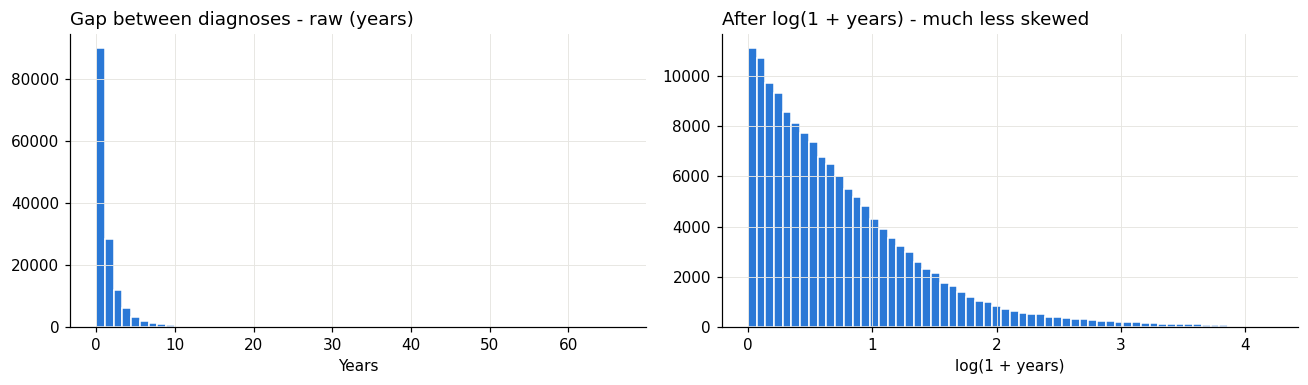

In [46]:
#scaling the time gap
# Ages go 0-80 -> divide by 80.  Gaps go from 0 days to decades -> log(1 + years).
# Diagnosis codes are categories, so they are NOT scaled (the model uses embeddings).
all_gaps = []
for tokens, ages in seqs["fit"].values():
    all_gaps.extend(np.diff(ages[1:]))           # gaps between diagnoses
all_gaps = np.array(all_gaps)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(all_gaps, bins=60, color=BLUE, edgecolor="white")
axes[0].set_title("Gap between diagnoses - raw (years)", loc="left")
axes[0].set_xlabel("Years")
axes[1].hist(np.log1p(all_gaps), bins=60, color=BLUE, edgecolor="white")
axes[1].set_title("After log(1 + years) - much less skewed", loc="left")
axes[1].set_xlabel("log(1 + years)")
plt.tight_layout()
save_fig("prep_2_scaling.png")
plt.show()

,train,test,test used,p-value
% female,50.9,51.3,chi-square,0.725
diagnoses per patient (median),23.0,22.0,Mann-Whitney U,0.384
age at last record (median),79.4,79.3,Mann-Whitney U,0.017


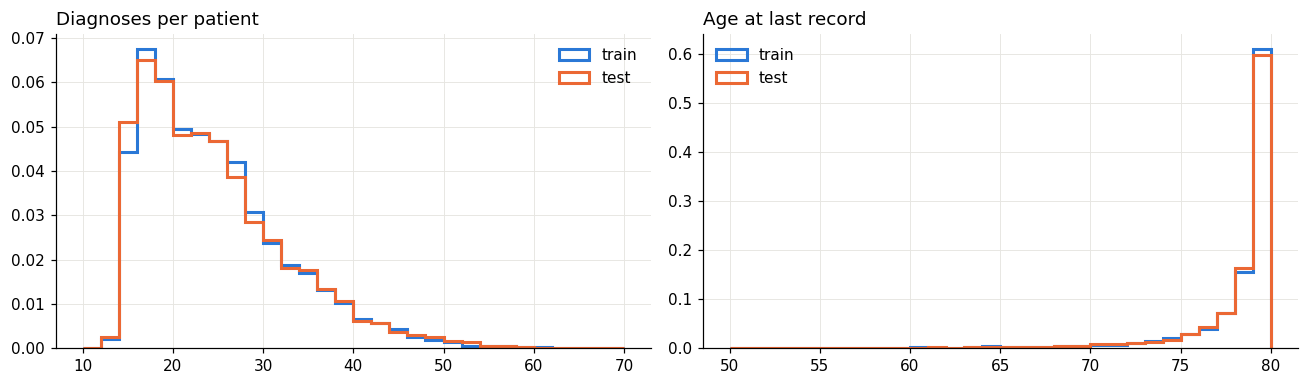

In [47]:
#Plot 9, train vs test statistical tests
pt_test = patient_summary(test)

# Sex: categories -> chi-square test
table = [[(pt_train.sex == "Female").sum(), (pt_train.sex == "Male").sum()],
         [(pt_test.sex == "Female").sum(), (pt_test.sex == "Male").sum()]]
p_sex = stats.chi2_contingency(table)[1]

# Counts and ages are skewed (not normal) -> Mann-Whitney U instead of a t-test
p_ndx = stats.mannwhitneyu(pt_train.n_dx, pt_test.n_dx).pvalue
p_last = stats.mannwhitneyu(pt_train.last_age, pt_test.last_age).pvalue

results = pd.DataFrame({
    "train": [f"{100 * (pt_train.sex == 'Female').mean():.1f}", pt_train.n_dx.median(), round(pt_train.last_age.median(), 1)],
    "test": [f"{100 * (pt_test.sex == 'Female').mean():.1f}", pt_test.n_dx.median(), round(pt_test.last_age.median(), 1)],
    "test used": ["chi-square", "Mann-Whitney U", "Mann-Whitney U"],
    "p-value": [round(p_sex, 3), round(p_ndx, 3), round(p_last, 3)],
}, index=["% female", "diagnoses per patient (median)", "age at last record (median)"])
display(results)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, col, title, bins in [(axes[0], "n_dx", "Diagnoses per patient", range(10, 72, 2)),
                              (axes[1], "last_age", "Age at last record", range(50, 81))]:
    ax.hist(pt_train[col], bins=bins, density=True, histtype="step", linewidth=2, color=BLUE, label="train")
    ax.hist(pt_test[col], bins=bins, density=True, histtype="step", linewidth=2, color=ORANGE, label="test")
    ax.set_title(title, loc="left")
    ax.legend(frameon=False)
plt.tight_layout()
save_fig("prep_3_train_vs_test.png")
plt.show()
# A small p-value with a tiny difference (e.g. one month in median age) is statistically
# significant but not practically important - with ~7,000 patients, tests detect tiny shifts.

In [51]:
processed = {
    "seqs": seqs,
    "examples": examples,
    "known_codes": known_codes,
    "vocab": vocab,
    "SEX_UNKNOWN": SEX_UNKNOWN,
    "UNK": UNK,
    "N_TOKENS": N_TOKENS,
    "AGE_SCALE": AGE_SCALE,
    "lr_inputs": lr_inputs,       # multi-hot tables for logistic regression
    "gru_inputs": gru_inputs,     # padded sequences for the GRU
}
with open(os.path.join(OUT_DIR, "processed.pkl"), "wb") as f:
    pickle.dump(processed, f)
print("Saved to", os.path.join(OUT_DIR, "processed.pkl"))

Saved to /content/outputs/processed.pkl


In [52]:
#logistic regression input, the multi-hot table
# One row per prediction example. One column per disease code (+ sex), set to 1 if the patient
# has had it BEFORE the prediction point, 0 if not. Plus one column for current age (scaled).
# Most cells are 0, so we store it as a "sparse" matrix (only the 1s are saved) to save memory.
from scipy import sparse

AGE_SCALE = 80.0                    # ages in this cohort go up to 80 -> scaled age is between 0 and 1
AGE_COL = N_TOKENS                  # last column holds the scaled current age
N_FEATURES = N_TOKENS + 1

# input version of each patient's tokens (unseen codes -> UNK), computed once per patient
inputs = {split: {pid: input_tokens(t) for pid, (t, _) in s.items()} for split, s in seqs.items()}


def multi_hot(split):
    ex = examples[split]
    rows, cols, vals = [], [], []
    for i, (pid, h, age) in enumerate(zip(ex.pid.values, ex.history_len.values, ex.current_age.values)):
        history = inputs[split][pid][:h]              # sex + earlier diagnoses only
        rows.extend([i] * len(history))
        cols.extend(history)
        vals.extend([1.0] * len(history))
        rows.append(i)                                # current age column
        cols.append(AGE_COL)
        vals.append(age / AGE_SCALE)
    X = sparse.csr_matrix((vals, (rows, cols)), shape=(len(ex), N_FEATURES), dtype=np.float32)
    y = ex.target.values                              # the next diagnosis = what we predict
    return X, y


lr_inputs = {split: multi_hot(split) for split in ["fit", "tune", "test"]}
for split, (X, y) in lr_inputs.items():
    print(f"{split:5s}: X shape {X.shape} | y shape {y.shape} | {100 * X.nnz / (X.shape[0] * X.shape[1]):.2f}% of cells are non-zero")

# What one row looks like: patient 402868, 4th prediction
X_fit, y_fit = lr_inputs["fit"]
i = examples["fit"].index[(examples["fit"].pid == 402868)][3]
row = X_fit[i]
print("\nPatient 402868, prediction 4")
print("  columns set to 1:", [code_of[c] for c in row.indices if c != AGE_COL])
print("  scaled age column:", round(row[0, AGE_COL], 3), f"(= {row[0, AGE_COL] * AGE_SCALE:.1f} years / 80)")
print("  target (y):", code_of[y_fit[i]])

fit  : X shape (155303, 1000) | y shape (155303,) | 1.49% of cells are non-zero
tune : X shape (16945, 1000) | y shape (16945,) | 1.47% of cells are non-zero
test : X shape (172280, 1000) | y shape (172280,) | 1.49% of cells are non-zero

Patient 402868, prediction 4
  columns set to 1: ['Female', 'F34', 'M54', 'O80']
  scaled age column: 0.488 (= 39.1 years / 80)
  target (y): M51


In [53]:
# One row per diagnosis, with the patient's sex attached (sex is recorded once per patient).
sex_of = train[train.token.isin([1, 2])].set_index("pid").token.map({1: "Female", 2: "Male"})

full = train[train.token >= 3][["pid", "age", "code", "name", "chapter"]].copy()
full.insert(1, "sex", full.pid.map(sex_of))
full["age_band"] = pd.cut(full.age, bins=[0, 20, 40, 50, 60, 70, 80.01], right=False,
                          labels=["0-19", "20-39", "40-49", "50-59", "60-69", "70-80"])

print(f"{len(full):,} diagnoses from {full.pid.nunique():,} patients")
print("Missing values in each column:", full.isna().sum().to_dict())
display(full.round(1).head(10))

full.to_csv(os.path.join(OUT_DIR, "train_clean.csv"), index=False)     # readable copy of the clean data

# How many diagnoses fall in each age band, for women and men
display(pd.crosstab(full.age_band, full.sex, margins=True, margins_name="Total"))

172,248 diagnoses from 7,143 patients
Missing values in each column: {'pid': 0, 'sex': 0, 'age': 0, 'code': 0, 'name': 0, 'chapter': 0, 'age_band': 0}


,pid,sex,age,code,name,chapter,age_band
1,402867,Male,3.4,J45,J45 (asthma),J,0-19
2,402867,Male,24.3,L30,L30 (other dermatitis),L,20-39
3,402867,Male,42.5,L20,L20 (atopic dermatitis),L,40-49
4,402867,Male,58.7,I10,I10 (essential (primary) hypertension),I,50-59
5,402867,Male,59.8,E78,E78 (disorders of lipoprotein metabolism and other lipid...,E,50-59
6,402867,Male,59.9,M79,"M79 (other soft tissue disorders, not elsewhere classified)",M,50-59
7,402867,Male,60.6,G25,G25 (other extrapyramidal and movement disorders),G,60-69
8,402867,Male,63.7,K40,K40 (inguinal hernia),K,60-69
9,402867,Male,64.2,G44,G44 (other headache syndromes),G,60-69
10,402867,Male,65.2,C61,C61 Malignant neoplasm of prostate,C,60-69


sex,Female,Male,Total
age_band,,,
0-19,1244,1188,2432
20-39,4339,2522,6861
40-49,6992,5099,12091
50-59,15347,12741,28088
60-69,24686,23938,48624
70-80,37684,36468,74152
Total,90292,81956,172248


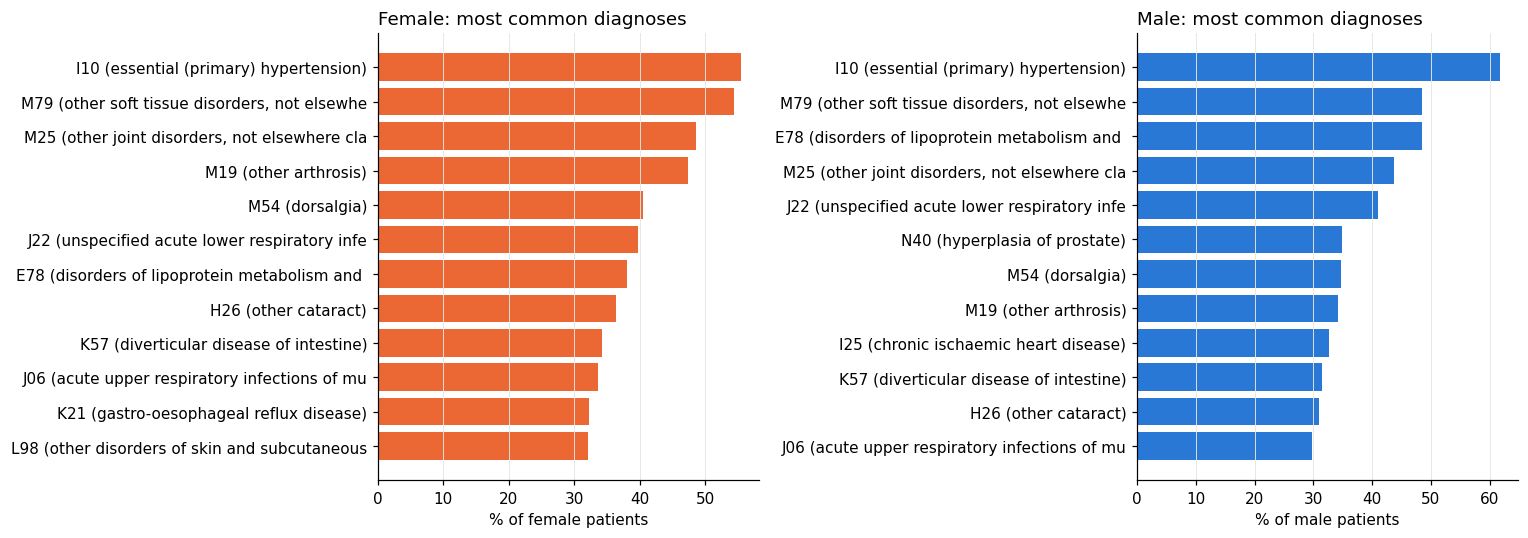

Most female-skewed:


sex,name,Female,Male
code,,,
N95,N95 (menopausal and other perimenopausal disorders),26.3,0.1
N92,"N92 (excessive, frequent and irregular menstruation)",12.2,0.1
N81,N81 (female genital prolapse),13.0,0.1
N83,"N83 (noninflammatory disorders of ovary, fallopian tube ...",5.9,0.0
O80,O80 (single spontaneous delivery),7.6,0.0


Most male-skewed:


sex,name,Female,Male
code,,,
N40,N40 (hyperplasia of prostate),0.2,34.9
C61,C61 Malignant neoplasm of prostate,0.0,11.6
N48,N48 (other disorders of penis),0.0,8.4
N50,N50 (other disorders of male genital organs),0.1,11.9
N41,N41 (inflammatory diseases of prostate),0.0,5.9


Women with a male-only diagnosis: 17 diagnoses in 17 patients
Men with a female-only diagnosis: 39 diagnoses in 38 patients
Total: 0.03% of all diagnoses -> kept (too few to matter), reported as a limitation


In [54]:
n_by_sex = sex_of.value_counts()                     # number of women and men

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, sex, colour in [(axes[0], "Female", ORANGE), (axes[1], "Male", BLUE)]:
    top = full[full.sex == sex].name.value_counts().head(12)
    pct = 100 * top / n_by_sex[sex]                  # % of women (or men) with this diagnosis
    ax.barh([n[:45] for n in pct.index[::-1]], pct.values[::-1], color=colour)
    ax.set_title(f"{sex}: most common diagnoses", loc="left")
    ax.set_xlabel(f"% of {sex.lower()} patients")
    ax.grid(axis="y", visible=False)
plt.tight_layout()
save_fig("eda_7_top_by_sex.png")
plt.show()

# Diagnoses that are much more common in one sex (shows why sex is a useful input)
rate = full.groupby(["code", "sex"]).pid.nunique().unstack(fill_value=0) / n_by_sex * 100
rate = rate[(rate.Female + rate.Male) >= 2]          # ignore very rare codes
rate["ratio F/M"] = (rate.Female + 0.1) / (rate.Male + 0.1)
rate["name"] = rate.index.map(dict(zip(vocab.code, vocab.name)))
print("Most female-skewed:")
display(rate.sort_values("ratio F/M", ascending=False).head(5)[["name", "Female", "Male"]].round(1))
print("Most male-skewed:")
display(rate.sort_values("ratio F/M").head(5)[["name", "Female", "Male"]].round(1))

# Data quality check: diagnoses that don't match the recorded sex (e.g. prostate disease in a woman)
# male_only / female_only lists come from cell 6b
wrong_f = full[(full.sex == "Female") & full.code.isin(male_only)]
wrong_m = full[(full.sex == "Male") & full.code.isin(female_only)]
print(f"Women with a male-only diagnosis: {len(wrong_f)} diagnoses in {wrong_f.pid.nunique()} patients")
print(f"Men with a female-only diagnosis: {len(wrong_m)} diagnoses in {wrong_m.pid.nunique()} patients")
print(f"Total: {100 * (len(wrong_f) + len(wrong_m)) / len(full):.2f}% of all diagnoses -> kept (too few to matter), reported as a limitation")

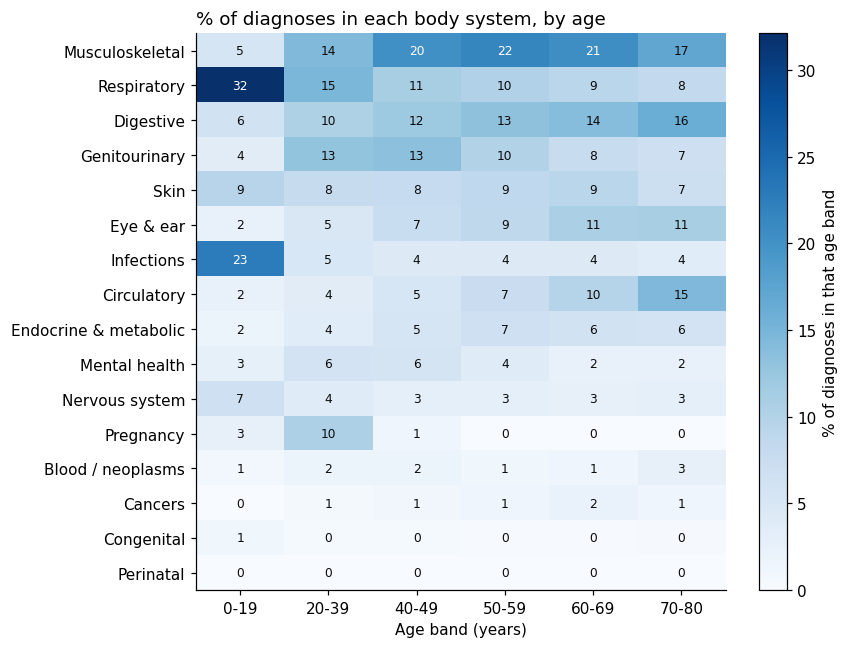

In [55]:
# Each column adds up to 100%: "of all diagnoses in this age band, what % are in each body system"
table = pd.crosstab(full.chapter.map(chapter_names), full.age_band, normalize="columns") * 100
table = table.loc[table.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(table.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(table.columns)))
ax.set_xticklabels(table.columns)
ax.set_yticks(range(len(table.index)))
ax.set_yticklabels(table.index)
ax.grid(False)
for r in range(table.shape[0]):
    for c in range(table.shape[1]):
        v = table.values[r, c]
        ax.text(c, r, f"{v:.0f}", ha="center", va="center", fontsize=8,
                color="white" if v > table.values.max() * 0.6 else "#0b0b0b")
ax.set_xlabel("Age band (years)")
ax.set_title("% of diagnoses in each body system, by age", loc="left")
plt.colorbar(im, ax=ax, label="% of diagnoses in that age band")
plt.tight_layout()
save_fig("eda_8_system_by_age.png")
plt.show()

In [56]:
# This is exactly what the simplest baseline will predict: "the most common diagnoses
# for someone of your age and sex". The GRU has to beat this.
def top3(g):
    return ", ".join(g.code.value_counts().head(3).index)

summary = full.groupby(["age_band", "sex"], observed=True).apply(top3).unstack()
display(summary)

/tmp/ipykernel_5654/2526475638.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = full.groupby(["age_band", "sex"], observed=True).apply(top3).unstack()


sex,Female,Male
age_band,,
0-19,"J45, J30, B01","J45, J30, B01"
20-39,"O80, J45, F32","J45, J30, M54"
40-49,"N92, M25, M54","M25, E78, M54"
50-59,"M79, N95, M25","E78, M25, I10"
60-69,"M79, I10, M25","I10, M79, E78"
70-80,"I10, H26, K57","I10, H26, I25"


In [50]:
#GRU input, padded sequences
# The GRU reads each patient's history in order, one event at a time, and makes a prediction
# after every step. So we store one row per PATIENT (not per example), with 3 inputs per event:
#   code      - which disease (an integer id, turned into an embedding inside the model)
#   age       - age at that event / 80                  (scaled to 0-1)
#   gap       - log(1 + years since the previous event) (scaled, see plot 8)
# Patients have different lengths, so shorter ones are padded with 0 at the end.
MAX_LEN = max(len(t) for s in seqs.values() for t, _ in s.values())


def gru_arrays(split):
    pids = list(seqs[split].keys())
    n = len(pids)
    codes = np.zeros((n, MAX_LEN), dtype=np.int64)      # 0 = padding
    age = np.zeros((n, MAX_LEN), dtype=np.float32)
    gap = np.zeros((n, MAX_LEN), dtype=np.float32)
    lengths = np.zeros(n, dtype=np.int64)
    for i, pid in enumerate(pids):
        tokens, ages = seqs[split][pid]
        L = len(tokens)
        codes[i, :L] = inputs[split][pid]
        age[i, :L] = ages / AGE_SCALE
        gap[i, 1:L] = np.log1p(np.diff(ages))           # first event (sex) has no previous event
        lengths[i] = L
    return {"pids": pids, "row_of": {pid: i for i, pid in enumerate(pids)},
            "codes": codes, "age": age, "gap": gap, "lengths": lengths}


gru_inputs = {split: gru_arrays(split) for split in ["fit", "tune", "test"]}
for split, g in gru_inputs.items():
    print(f"{split:5s}: codes/age/gap arrays of shape {g['codes'].shape}  (patients x max events)")

# Each prediction example points to a step in its patient's row:
# the GRU's output after reading `history_len` events predicts the target.
g = gru_inputs["fit"]
r = g["row_of"][402868]
L = g["lengths"][r]
print(f"\nPatient 402868 as the GRU sees it (first 8 of {L} events, then padding up to {MAX_LEN}):")
display(pd.DataFrame({
    "code": [code_of[c] for c in g["codes"][r, :8]],
    "age (scaled)": g["age"][r, :8].round(3),
    "gap (scaled)": g["gap"][r, :8].round(3),
}))

fit  : codes/age/gap arrays of shape (6429, 69)  (patients x max events)
tune : codes/age/gap arrays of shape (714, 69)  (patients x max events)
test : codes/age/gap arrays of shape (7143, 69)  (patients x max events)

Patient 402868 as the GRU sees it (first 8 of 36 events, then padding up to 69):


,code,age (scaled),gap (scaled)
0,Female,0.000,0.000
1,O80,0.383,3.454
2,M54,0.476,2.139
3,F34,0.488,0.676
4,M51,0.508,0.933
5,M77,0.557,1.598
6,N84,0.582,1.103
7,K64,0.611,1.193


In [57]:
# If the session was reset: upload processed.pkl to /content/outputs/ first
# (it's inside the outputs.zip you downloaded with cell 23).
import os
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from IPython.display import display

OUT_DIR = "/content/outputs" if os.path.exists("/content") else "./outputs"

with open(os.path.join(OUT_DIR, "processed.pkl"), "rb") as f:
    P = pickle.load(f)

seqs, examples, known_codes, vocab = P["seqs"], P["examples"], P["known_codes"], P["vocab"]
N_TOKENS, UNK, SEX_UNKNOWN = P["N_TOKENS"], P["UNK"], P["SEX_UNKNOWN"]
lr_inputs, gru_inputs = P["lr_inputs"], P["gru_inputs"]

code_of = dict(zip(vocab.token, vocab.code))
code_of.update({1: "Female", 2: "Male", SEX_UNKNOWN: "SEX?", UNK: "UNK"})
name_of = dict(zip(vocab.token, vocab.name))

# Use the GPU if Colab gives us one (Runtime -> Change runtime type -> T4 GPU); CPU also works
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
np.random.seed(0)
print("Device:", device)
for split in ["fit", "tune", "test"]:
    print(f"{split:5s}: {len(examples[split]):,} prediction examples")

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.6})
BLUE, ORANGE, GREEN = "#2a78d6", "#eb6834", "#1baf7a"
MODEL_COLOURS = {"Markov": GREEN, "Logistic regression": ORANGE, "GRU": BLUE}


def save_fig(name):
    plt.savefig(os.path.join(OUT_DIR, name), bbox_inches="tight", dpi=150)

Device: cpu
fit  : 155,303 prediction examples
tune : 16,945 prediction examples
test : 172,280 prediction examples


In [58]:
#shared evaluation code
# Every model gives a probability for each of the ~920 possible next diagnoses.
# Before scoring we apply the same two rules to every model:
#   1. only real diagnosis codes seen in training can be predicted
#   2. a code the patient ALREADY has can't be their next (new) diagnosis -> probability set to 0
# then we re-normalise so the probabilities add up to 1 again.
valid = np.zeros(N_TOKENS, dtype=np.float32)
valid[list(known_codes)] = 1.0

# Clinically important outcomes we report separately (same groups as in the EDA)
key_conditions = {
    "Coronary heart disease": ["I20", "I21", "I22", "I23", "I24", "I25"],
    "Atrial fibrillation": ["I48"],
    "Heart failure": ["I50"],
    "Stroke": ["I63", "I64"],
    "Type 2 diabetes": ["E11"],
    "Chronic kidney disease": ["N18"],
}
token_of_code = {c: t for t, c in zip(vocab.token, vocab.code) if t >= 3}
key_tokens = {k: [token_of_code[c] for c in codes if c in token_of_code] for k, codes in key_conditions.items()}


def history_of(split, i):
    # raw tokens the patient had before example i (sex + earlier diagnoses)
    ex = examples[split]
    tokens, _ = seqs[split][ex.pid.values[i]]
    return tokens[:ex.history_len.values[i]]


def score_batch(split, idx, probs):
    """Apply the rules above to a batch of predictions and record what we need for evaluation."""
    probs = probs * valid                                        # rule 1
    for row, i in enumerate(idx):
        probs[row, history_of(split, i)] = 0.0                   # rule 2
    probs = probs / probs.sum(axis=1, keepdims=True)

    targets = examples[split].target.values[idx]
    p_true = probs[np.arange(len(idx)), targets]
    # rank of the true diagnosis among all candidates (1 = model's top guess)
    rank = 1 + (probs > p_true[:, None]).sum(axis=1)
    rank = np.where(valid[targets] > 0, rank, 10**6)             # never-seen codes = always a miss
    out = {"idx": idx, "p_true": p_true, "rank": rank, "top1": probs.argmax(axis=1)}
    for k, toks in key_tokens.items():
        out["p_" + k] = probs[:, toks].sum(axis=1)               # P(next diagnosis is in this group)
    return out


def evaluate(batches, split):
    """batches = generator of (example indices, probability matrix). Returns one row per example."""
    parts = [score_batch(split, idx, probs) for idx, probs in batches]
    res = pd.DataFrame({k: np.concatenate([p[k] for p in parts]) for k in parts[0]}).sort_values("idx")
    ex = examples[split].iloc[res.idx.values]
    res["pid"] = ex.pid.values
    res["target"] = ex.target.values
    res["current_age"] = ex.current_age.values
    res["history_len"] = ex.history_len.values
    return res.reset_index(drop=True)


def summary(res):
    ok = res["rank"] < 10**6
    return {
        "top-1 acc %": 100 * (res["rank"] <= 1).mean(),
        "top-5 acc %": 100 * (res["rank"] <= 5).mean(),
        "top-10 acc %": 100 * (res["rank"] <= 10).mean(),
        "log-loss": -np.log(np.clip(res.p_true[ok], 1e-12, 1)).mean(),   # lower = better
    }

In [59]:
#Model 1, Markov
# Count, in the fit set, how often each diagnosis follows each "last event".
# For rare "last events" there are few counts, so we blend with the overall frequency of each
# diagnosis (smoothing). alpha controls how much we blend - chosen on the TUNE set.
last_token = {}
for split in ["fit", "tune", "test"]:
    ex = examples[split]
    inp = gru_inputs[split]
    rows = np.array([inp["row_of"][p] for p in ex.pid.values])
    last_token[split] = inp["codes"][rows, ex.history_len.values - 1]      # last visible event (input version)

counts = np.zeros((N_TOKENS, N_TOKENS), dtype=np.float64)
np.add.at(counts, (last_token["fit"], examples["fit"].target.values), 1)
overall = np.bincount(examples["fit"].target.values, minlength=N_TOKENS).astype(np.float64)
overall = overall / overall.sum()


def markov_batches(split, alpha, batch=4096):
    n = len(examples[split])
    for s in range(0, n, batch):
        idx = np.arange(s, min(s + batch, n))
        last = last_token[split][idx]
        probs = (counts[last] + alpha * overall) / (counts[last].sum(axis=1, keepdims=True) + alpha)
        yield idx, probs.astype(np.float32)


# choose alpha on the tune set (lower log-loss = better)
tuning = []
for alpha in [1, 10, 100, 1000, 10000, 100000]:
    tuning.append({"alpha": alpha, **summary(evaluate(markov_batches("tune", alpha), "tune"))})
tuning = pd.DataFrame(tuning)
display(tuning.round(3))
best_alpha = int(tuning.loc[tuning["log-loss"].idxmin(), "alpha"])
print("Chosen alpha:", best_alpha)

,alpha,top-1 acc %,top-5 acc %,top-10 acc %,log-loss
0,1,4.745,14.813,22.520,6.330
1,10,4.745,14.813,22.520,5.867
2,100,4.792,15.108,22.939,5.507
3,1000,4.627,14.972,23.458,5.374
4,10000,3.724,13.691,21.617,5.426
5,100000,3.393,12.906,20.384,5.467


Chosen alpha: 1000


In [60]:
#Model 2, logistic regression
# Multinomial logistic regression = one linear layer + softmax over ~1,000 possible diagnoses.
# Written in PyTorch because scikit-learn is very slow with this many classes; mathematically
# it is the same model. Weight decay = L2 regularisation. Training stops when the TUNE loss
# stops improving (early stopping).
class LogisticRegression(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.linear = nn.Linear(n_features, n_classes)

    def forward(self, x):
        return self.linear(x)                  # logits; softmax is applied in the loss / prediction


def lr_batches(model, split, batch=2048, shuffle=False):
    X, y = lr_inputs[split]
    order = np.random.permutation(X.shape[0]) if shuffle else np.arange(X.shape[0])
    for s in range(0, len(order), batch):
        idx = order[s:s + batch]
        xb = torch.tensor(X[idx].toarray(), device=device)     # sparse rows -> small dense batch
        yb = torch.tensor(y[idx], device=device)
        yield idx, xb, yb


def train_with_early_stopping(model, train_step, tune_loss, max_epochs=30, patience=3, name="model"):
    best, best_state, bad, history = np.inf, None, 0, []
    for epoch in range(1, max_epochs + 1):
        t0 = time.time()
        fit_loss = train_step()
        val_loss = tune_loss()
        history.append((epoch, fit_loss, val_loss))
        print(f"{name} epoch {epoch:2d} | fit loss {fit_loss:.3f} | tune loss {val_loss:.3f} | {time.time() - t0:.0f}s")
        if val_loss < best - 1e-4:
            best, bad = val_loss, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                print(f"Stopping: tune loss has not improved for {patience} epochs")
                break
    model.load_state_dict(best_state)          # keep the best version, not the last one
    return pd.DataFrame(history, columns=["epoch", "fit loss", "tune loss"])


lr_model = LogisticRegression(lr_inputs["fit"][0].shape[1], N_TOKENS).to(device)
lr_opt = torch.optim.Adam(lr_model.parameters(), lr=1e-3, weight_decay=1e-6)


def lr_train_step():
    lr_model.train()
    total, n = 0.0, 0
    for _, xb, yb in lr_batches(lr_model, "fit", shuffle=True):
        loss = F.cross_entropy(lr_model(xb), yb)
        lr_opt.zero_grad()
        loss.backward()
        lr_opt.step()
        total += loss.item() * len(yb)
        n += len(yb)
    return total / n


@torch.no_grad()
def lr_tune_loss():
    lr_model.eval()
    total, n = 0.0, 0
    for _, xb, yb in lr_batches(lr_model, "tune"):
        total += F.cross_entropy(lr_model(xb), yb, reduction="sum").item()
        n += len(yb)
    return total / n


lr_history = train_with_early_stopping(lr_model, lr_train_step, lr_tune_loss, name="LogReg")


@torch.no_grad()
def lr_predict(split):
    lr_model.eval()
    for idx, xb, _ in lr_batches(lr_model, split):
        yield idx, F.softmax(lr_model(xb), dim=1).cpu().numpy()

LogReg epoch  1 | fit loss 6.454 | tune loss 6.126 | 11s
LogReg epoch  2 | fit loss 5.909 | tune loss 5.860 | 11s
LogReg epoch  3 | fit loss 5.692 | tune loss 5.744 | 11s
LogReg epoch  4 | fit loss 5.563 | tune loss 5.671 | 11s
LogReg epoch  5 | fit loss 5.465 | tune loss 5.619 | 11s
LogReg epoch  6 | fit loss 5.383 | tune loss 5.579 | 11s
LogReg epoch  7 | fit loss 5.313 | tune loss 5.546 | 12s
LogReg epoch  8 | fit loss 5.250 | tune loss 5.519 | 11s
LogReg epoch  9 | fit loss 5.194 | tune loss 5.497 | 11s
LogReg epoch 10 | fit loss 5.144 | tune loss 5.479 | 11s
LogReg epoch 11 | fit loss 5.098 | tune loss 5.464 | 11s
LogReg epoch 12 | fit loss 5.055 | tune loss 5.452 | 11s
LogReg epoch 13 | fit loss 5.017 | tune loss 5.442 | 11s
LogReg epoch 14 | fit loss 4.981 | tune loss 5.434 | 11s
LogReg epoch 15 | fit loss 4.948 | tune loss 5.428 | 11s
LogReg epoch 16 | fit loss 4.917 | tune loss 5.424 | 12s
LogReg epoch 17 | fit loss 4.889 | tune loss 5.420 | 11s
LogReg epoch 18 | fit loss 4.86

In [61]:
# FOR GRU
#For each event the GRU gets: the diagnosis (as a learned 64-number embedding),
# the age at that event, and the gap since the previous event. It reads the events in order
# and after every step outputs probabilities for the next diagnosis.
class GRUModel(nn.Module):
    def __init__(self, n_tokens, emb_dim=64, hidden=128, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(n_tokens, emb_dim, padding_idx=0)
        self.gru = nn.GRU(emb_dim + 2, hidden, batch_first=True)    # +2 = age and gap
        self.dropout = nn.Dropout(dropout)
        self.output = nn.Linear(hidden, n_tokens)

    def hidden_states(self, codes, age, gap):
        x = torch.cat([self.embedding(codes), age.unsqueeze(-1), gap.unsqueeze(-1)], dim=-1)
        h, _ = self.gru(x)                     # one hidden state per event: (patients, events, hidden)
        return h

    def forward(self, codes, age, gap, rows, positions):
        # logits for the requested (patient row, position) pairs only
        h = self.hidden_states(codes, age, gap)
        return self.output(self.dropout(h[rows, positions]))


# For every example: which patient row in the GRU arrays, and at which position to read the output.
# The output after reading `history_len` events (position history_len - 1) predicts the target.
ex_index = {}
for split in ["fit", "tune", "test"]:
    ex = examples[split]
    rows = np.array([gru_inputs[split]["row_of"][p] for p in ex.pid.values])
    starts = np.searchsorted(rows, np.arange(len(gru_inputs[split]["pids"]) + 1))
    ex_index[split] = {"rows": rows, "pos": ex.history_len.values - 1, "starts": starts}


def gru_batches(split, batch_patients=64, shuffle=False, zero_time=False):
    g, e = gru_inputs[split], ex_index[split]
    n = len(g["pids"])
    order = np.random.permutation(n) if shuffle else np.arange(n)
    for s in range(0, n, batch_patients):
        pats = order[s:s + batch_patients]
        L = g["lengths"][pats].max()                                   # trim padding to the longest in batch
        codes = torch.tensor(g["codes"][pats, :L], device=device)
        age = torch.tensor(g["age"][pats, :L], device=device)
        gap = torch.tensor(g["gap"][pats, :L], device=device)
        if zero_time:                                                  # used for a sanity check later
            age, gap = torch.zeros_like(age), torch.zeros_like(gap)
        idx = np.concatenate([np.arange(e["starts"][p], e["starts"][p + 1]) for p in pats])
        local_row = np.repeat(np.arange(len(pats)), [e["starts"][p + 1] - e["starts"][p] for p in pats])
        rows_t = torch.tensor(local_row, device=device)
        pos_t = torch.tensor(e["pos"][idx], device=device)
        y = torch.tensor(examples[split].target.values[idx], device=device)
        yield idx, (codes, age, gap, rows_t, pos_t), y


gru_model = GRUModel(N_TOKENS).to(device)
gru_opt = torch.optim.Adam(gru_model.parameters(), lr=2e-3)
print(f"GRU parameters: {sum(p.numel() for p in gru_model.parameters()):,}")


def gru_train_step():
    gru_model.train()
    total, n = 0.0, 0
    for _, inputs, y in gru_batches("fit", shuffle=True):
        loss = F.cross_entropy(gru_model(*inputs), y)
        gru_opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(gru_model.parameters(), 1.0)          # keeps training stable
        gru_opt.step()
        total += loss.item() * len(y)
        n += len(y)
    return total / n


@torch.no_grad()
def gru_tune_loss():
    gru_model.eval()
    total, n = 0.0, 0
    for _, inputs, y in gru_batches("tune"):
        total += F.cross_entropy(gru_model(*inputs), y, reduction="sum").item()
        n += len(y)
    return total / n


gru_history = train_with_early_stopping(gru_model, gru_train_step, gru_tune_loss, name="GRU")


@torch.no_grad()
def gru_predict(split, zero_time=False):
    gru_model.eval()
    for idx, inputs, _ in gru_batches(split, zero_time=zero_time):
        yield idx, F.softmax(gru_model(*inputs), dim=1).cpu().numpy()

GRU parameters: 268,071
GRU epoch  1 | fit loss 5.679 | tune loss 5.435 | 10s
GRU epoch  2 | fit loss 5.393 | tune loss 5.359 | 8s
GRU epoch  3 | fit loss 5.323 | tune loss 5.317 | 8s
GRU epoch  4 | fit loss 5.273 | tune loss 5.290 | 9s
GRU epoch  5 | fit loss 5.232 | tune loss 5.273 | 8s
GRU epoch  6 | fit loss 5.197 | tune loss 5.262 | 7s
GRU epoch  7 | fit loss 5.167 | tune loss 5.254 | 7s
GRU epoch  8 | fit loss 5.136 | tune loss 5.248 | 8s
GRU epoch  9 | fit loss 5.110 | tune loss 5.247 | 7s
GRU epoch 10 | fit loss 5.085 | tune loss 5.244 | 7s
GRU epoch 11 | fit loss 5.059 | tune loss 5.248 | 8s
GRU epoch 12 | fit loss 5.037 | tune loss 5.255 | 8s
GRU epoch 13 | fit loss 5.010 | tune loss 5.264 | 7s
Stopping: tune loss has not improved for 3 epochs


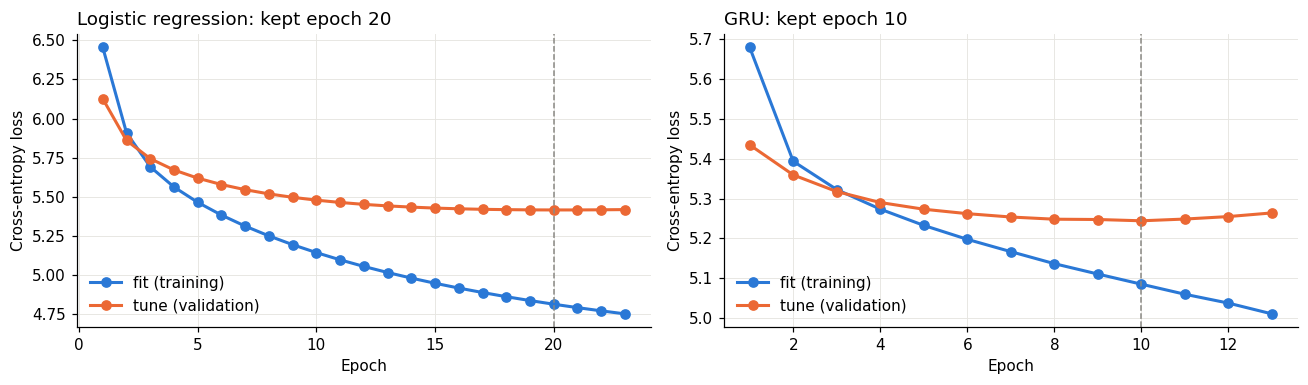

In [62]:
#Plot 10, training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, hist, title in [(axes[0], lr_history, "Logistic regression"), (axes[1], gru_history, "GRU")]:
    ax.plot(hist.epoch, hist["fit loss"], color=BLUE, linewidth=2, marker="o", label="fit (training)")
    ax.plot(hist.epoch, hist["tune loss"], color=ORANGE, linewidth=2, marker="o", label="tune (validation)")
    best = hist.loc[hist["tune loss"].idxmin()]
    ax.axvline(best.epoch, color="#8a8984", linestyle="--", linewidth=1)
    ax.set_title(f"{title}: kept epoch {int(best.epoch)}", loc="left")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.legend(frameon=False)
plt.tight_layout()
save_fig("model_1_training_curves.png")
plt.show()

TEST DATA EVALUATION

In [63]:
results = {
    "Markov": evaluate(markov_batches("test", best_alpha), "test"),
    "Logistic regression": evaluate(lr_predict("test"), "test"),
    "GRU": evaluate(gru_predict("test"), "test"),
}


def bootstrap_ci(res, metric, n_boot=200, seed=0):
    # resample PATIENTS (not single predictions), because predictions from one patient are related
    rng = np.random.default_rng(seed)
    per_patient = res.assign(hit=metric(res)).groupby("pid").hit.agg(["sum", "count"])
    s, c = per_patient["sum"].values, per_patient["count"].values
    stats_ = []
    for _ in range(n_boot):
        pick = rng.integers(0, len(s), len(s))
        stats_.append(s[pick].sum() / c[pick].sum())
    return np.percentile(stats_, [2.5, 97.5])


table = []
for name, res in results.items():
    row = {"model": name, **summary(res)}
    lo, hi = bootstrap_ci(res, lambda r: (r["rank"] <= 10).astype(float))
    row["top-10 95% CI"] = f"{100 * lo:.1f} - {100 * hi:.1f}"
    table.append(row)
main_table = pd.DataFrame(table).set_index("model")
display(main_table.round(2))
print("Reference: always guessing the most common code (I10) gets top-1 accuracy of about 2.4%")

,top-1 acc %,top-5 acc %,top-10 acc %,log-loss,top-10 95% CI
model,,,,,
Markov,4.65,15.37,23.46,5.37,23.3 - 23.7
Logistic regression,4.70,15.51,24.18,5.38,24.0 - 24.4
GRU,5.43,16.82,25.84,5.18,25.6 - 26.0


Reference: always guessing the most common code (I10) gets top-1 accuracy of about 2.4%


In [64]:
#IS GRU REALLY BETTER?
# Same test patients for both models -> compare them on the same resampled patients.
def paired_difference(res_a, res_b, n_boot=500, seed=0):
    rng = np.random.default_rng(seed)
    a = res_a.assign(h=(res_a["rank"] <= 10).astype(float)).groupby("pid").h.agg(["sum", "count"])
    b = res_b.assign(h=(res_b["rank"] <= 10).astype(float)).groupby("pid").h.agg(["sum", "count"]).loc[a.index]
    diffs = []
    for _ in range(n_boot):
        pick = rng.integers(0, len(a), len(a))
        diffs.append(a["sum"].values[pick].sum() / a["count"].values[pick].sum()
                     - b["sum"].values[pick].sum() / b["count"].values[pick].sum())
    diffs = 100 * np.array(diffs)
    return diffs.mean(), np.percentile(diffs, [2.5, 97.5])


for other in ["Logistic regression", "Markov"]:
    mean, (lo, hi) = paired_difference(results["GRU"], results[other])
    verdict = "GRU is better" if lo > 0 else ("GRU is worse" if hi < 0 else "no clear difference")
    print(f"GRU minus {other}: {mean:+.2f} percentage points top-10 accuracy (95% CI {lo:+.2f} to {hi:+.2f}) -> {verdict}")

GRU minus Logistic regression: +1.66 percentage points top-10 accuracy (95% CI +1.49 to +1.85) -> GRU is better
GRU minus Markov: +2.37 percentage points top-10 accuracy (95% CI +2.21 to +2.53) -> GRU is better


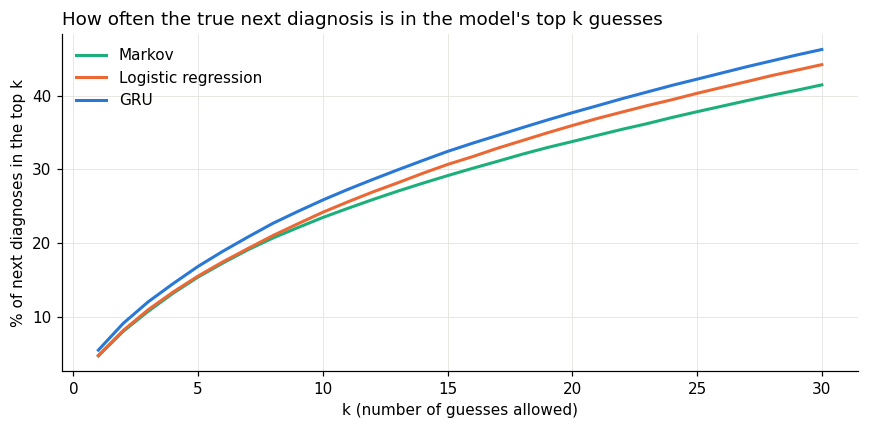

In [65]:
#top-k accuracy curve
ks = np.arange(1, 31)
fig, ax = plt.subplots(figsize=(8, 4))
for name, res in results.items():
    ax.plot(ks, [100 * (res["rank"] <= k).mean() for k in ks], linewidth=2, color=MODEL_COLOURS[name], label=name)
ax.set_xlabel("k (number of guesses allowed)")
ax.set_ylabel("% of next diagnoses in the top k")
ax.set_title("How often the true next diagnosis is in the model's top k guesses", loc="left")
ax.legend(frameon=False)
plt.tight_layout()
save_fig("model_2_topk.png")
plt.show()

In [66]:
#clinical lens, key conditions ka AUC
# For each condition: label = "was the next diagnosis this condition?", score = model's probability.
# AUC: 0.5 = random, 1.0 = perfect ranking of patients.
rows = []
for cond in key_conditions:
    label = results["GRU"].target.isin(key_tokens[cond]).values
    row = {"condition": cond, "cases in test": int(label.sum())}
    for name, res in results.items():
        row[name] = roc_auc_score(label, res["p_" + cond])
    rows.append(row)
auc_table = pd.DataFrame(rows).set_index("condition")
display(auc_table.round(3))

,cases in test,Markov,Logistic regression,GRU
condition,,,,
Coronary heart disease,3424,0.621,0.708,0.765
Atrial fibrillation,1420,0.656,0.709,0.723
Heart failure,508,0.717,0.813,0.842
Stroke,534,0.637,0.635,0.711
Type 2 diabetes,1234,0.631,0.760,0.761
Chronic kidney disease,988,0.622,0.684,0.682


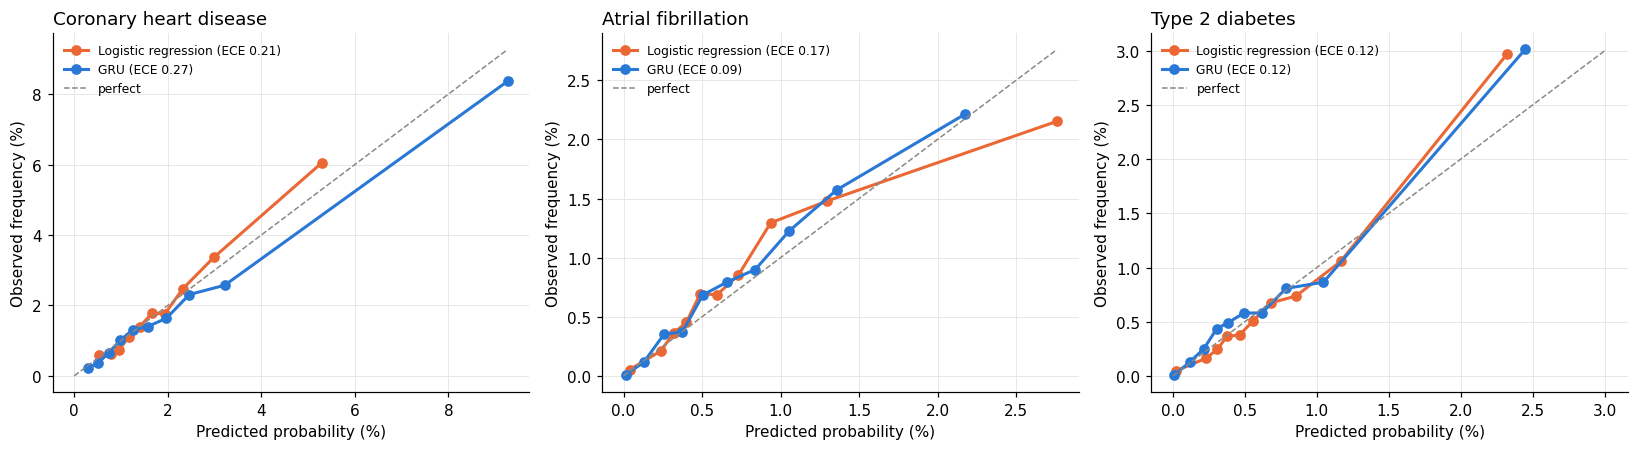

In [67]:
#calibration
def calibration_points(p, y, n_bins=10):
    bins = np.quantile(p, np.linspace(0, 1, n_bins + 1))
    which = np.clip(np.searchsorted(bins, p, side="right") - 1, 0, n_bins - 1)
    df = pd.DataFrame({"p": p, "y": y, "bin": which}).groupby("bin").agg(pred=("p", "mean"), obs=("y", "mean"), n=("y", "size"))
    ece = (df.n * (df.pred - df.obs).abs()).sum() / df.n.sum()          # expected calibration error
    return df, ece


plot_conditions = ["Coronary heart disease", "Atrial fibrillation", "Type 2 diabetes"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
ece_rows = []
for ax, cond in zip(axes, plot_conditions):
    label = results["GRU"].target.isin(key_tokens[cond]).values.astype(float)
    top = 0
    for name in ["Logistic regression", "GRU"]:
        df, ece = calibration_points(results[name]["p_" + cond].values, label)
        ax.plot(100 * df.pred, 100 * df.obs, marker="o", linewidth=2, color=MODEL_COLOURS[name], label=f"{name} (ECE {100 * ece:.2f})")
        top = max(top, df.pred.max(), df.obs.max())
        ece_rows.append({"condition": cond, "model": name, "ECE (% points)": 100 * ece})
    ax.plot([0, 100 * top], [0, 100 * top], color="#8a8984", linestyle="--", linewidth=1, label="perfect")
    ax.set_title(cond, loc="left")
    ax.set_xlabel("Predicted probability (%)")
    ax.set_ylabel("Observed frequency (%)")
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
save_fig("model_3_calibration.png")
plt.show()

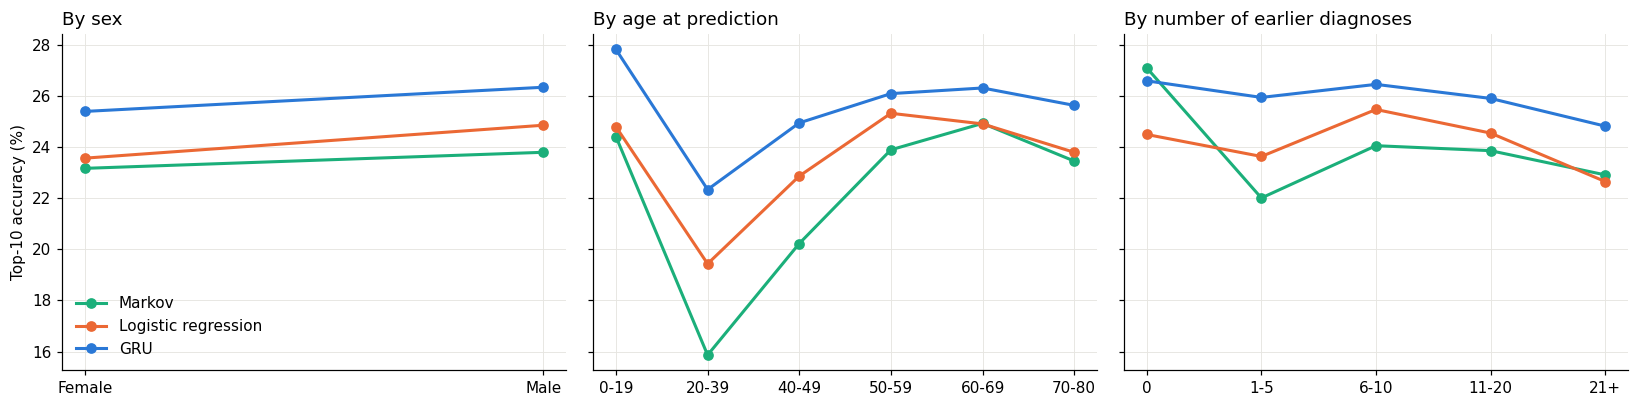

GRU top-10 accuracy by sex: {'Female': 25.4, 'Male': 26.3}


In [68]:
#Plot 13, subgroups (sex, age, history length)
def add_groups(res):
    first = {pid: int(t[0]) for pid, (t, _) in seqs["test"].items()}
    res = res.copy()
    res["sex"] = res.pid.map(first).map({1: "Female", 2: "Male"})
    res["age band"] = pd.cut(res.current_age, [-1, 20, 40, 50, 60, 70, 81],
                             labels=["0-19", "20-39", "40-49", "50-59", "60-69", "70-80"])
    res["history"] = pd.cut(res.history_len - 1, [-1, 0, 5, 10, 20, 70],
                            labels=["0", "1-5", "6-10", "11-20", "21+"])
    return res


grouped = {name: add_groups(res) for name, res in results.items()}
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
for ax, col, title in [(axes[0], "sex", "By sex"), (axes[1], "age band", "By age at prediction"),
                       (axes[2], "history", "By number of earlier diagnoses")]:
    for name, res in grouped.items():
        acc = res.groupby(col, observed=True)["rank"].apply(lambda r: 100 * (r <= 10).mean())
        ax.plot(acc.index.astype(str), acc.values, marker="o", linewidth=2, color=MODEL_COLOURS[name], label=name)
    ax.set_title(title, loc="left")
axes[0].set_ylabel("Top-10 accuracy (%)")
axes[0].legend(frameon=False)
plt.tight_layout()
save_fig("model_4_subgroups.png")
plt.show()

sub = grouped["GRU"].groupby("sex")["rank"].apply(lambda r: 100 * (r <= 10).mean())
print("GRU top-10 accuracy by sex:", sub.round(1).to_dict())

/tmp/ipykernel_5654/2819802600.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_freq = per_code.groupby("frequency group", observed=True).apply(


,codes,test cases,top-10 acc %
frequency group,,,
unseen,72.0,108.0,0.0
1-10,297.0,1660.0,0.1
11-50,227.0,6301.0,0.5
51-200,183.0,22446.0,2.1
201-1000,143.0,74241.0,11.0
1000+,37.0,67524.0,53.1


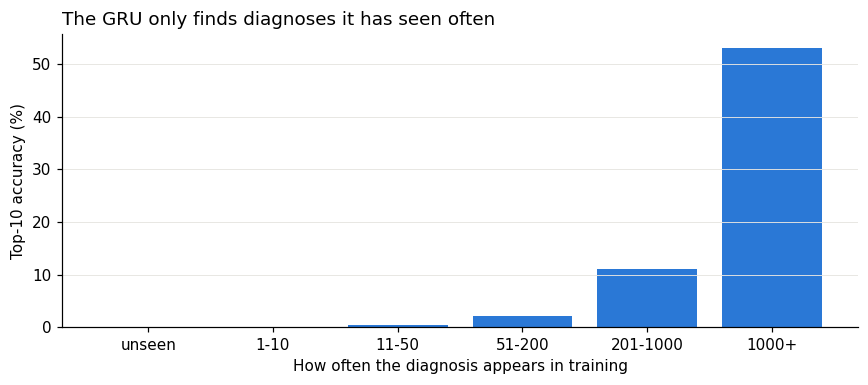

GRU's most frequent top-1 guesses (% of all predictions):
{'I10': 18.0, 'M79': 14.7, 'M25': 8.1, 'J22': 7.3, 'H26': 5.9, 'M19': 5.9, 'E78': 5.4, 'J45': 4.9, 'I25': 4.1, 'J06': 3.3}


In [69]:
#where GRU is failing
gru_res = results["GRU"]
fit_freq = examples["fit"].target.value_counts()
per_code = gru_res.assign(hit=gru_res["rank"] <= 10).groupby("target").hit.agg(["mean", "size"])
per_code["fit count"] = per_code.index.map(fit_freq).fillna(0)
per_code["frequency group"] = pd.cut(per_code["fit count"], [-1, 0, 10, 50, 200, 1000, 10**6],
                                     labels=["unseen", "1-10", "11-50", "51-200", "201-1000", "1000+"])
by_freq = per_code.groupby("frequency group", observed=True).apply(
    lambda g: pd.Series({"codes": len(g), "test cases": g["size"].sum(),
                         "top-10 acc %": 100 * (g["mean"] * g["size"]).sum() / g["size"].sum()}))
display(by_freq.round(1))

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(by_freq.index.astype(str), by_freq["top-10 acc %"], color=BLUE)
ax.set_xlabel("How often the diagnosis appears in training")
ax.set_ylabel("Top-10 accuracy (%)")
ax.set_title("The GRU only finds diagnoses it has seen often", loc="left")
ax.grid(axis="x", visible=False)
plt.tight_layout()
save_fig("model_5_failure_by_frequency.png")
plt.show()

# What does the GRU guess most often as its top-1? (does it just guess common codes?)
top_guesses = pd.Series(gru_res.top1).map(code_of).value_counts(normalize=True).head(10) * 100
print("GRU's most frequent top-1 guesses (% of all predictions):")
print(top_guesses.round(1).to_dict())

In [70]:
#GRU SANITY CHECK
# Check 1: does it use TIME? Remove age and gap information at test time.
no_time = evaluate(gru_predict("test", zero_time=True), "test")
print(f"Top-10 accuracy with timing: {100 * (gru_res['rank'] <= 10).mean():.1f}% | "
      f"with age/gap set to zero: {100 * (no_time['rank'] <= 10).mean():.1f}%")

# Check 2: does it use SEX sensibly? Same history, only the sex token changed.
@torch.no_grad()
def predict_one(tokens, ages):
    codes = torch.tensor([tokens], device=device)
    ages = np.array(ages, dtype=np.float32)
    age = torch.tensor(ages[None, :] / 80.0, device=device)
    gap = torch.tensor(np.r_[0, np.log1p(np.diff(ages))][None, :].astype(np.float32), device=device)
    gru_model.eval()
    h = gru_model.hidden_states(codes, age, gap)
    return F.softmax(gru_model.output(h[0, -1]), dim=0).cpu().numpy()


history_codes = ["I10", "E78", "M25"]                  # same history for both
history_tokens = [token_of_code[c] for c in history_codes]
ages = [0.0, 52.0, 53.5, 55.0]
checks = []
for sex_token, sex in [(1, "Female"), (2, "Male")]:
    p = predict_one([sex_token] + history_tokens, ages)
    checks.append({"sex": sex, **{f"P({c})": 100 * p[token_of_code[c]] for c in ["N95", "N40", "C61", "C50"]}})
print("\nSame history (I10, E78, M25 by age 55), only sex changed - probability of next diagnosis (%):")
display(pd.DataFrame(checks).set_index("sex").round(2))
# Expected: menopause (N95) and breast cancer (C50) higher for women; prostate (N40, C61) higher for men.

Top-10 accuracy with timing: 25.8% | with age/gap set to zero: 17.4%

Same history (I10, E78, M25 by age 55), only sex changed - probability of next diagnosis (%):


,P(N95),P(N40),P(C61),P(C50)
sex,,,,
Female,0.92,0.04,0.01,0.22
Male,0.02,1.96,0.44,0.01


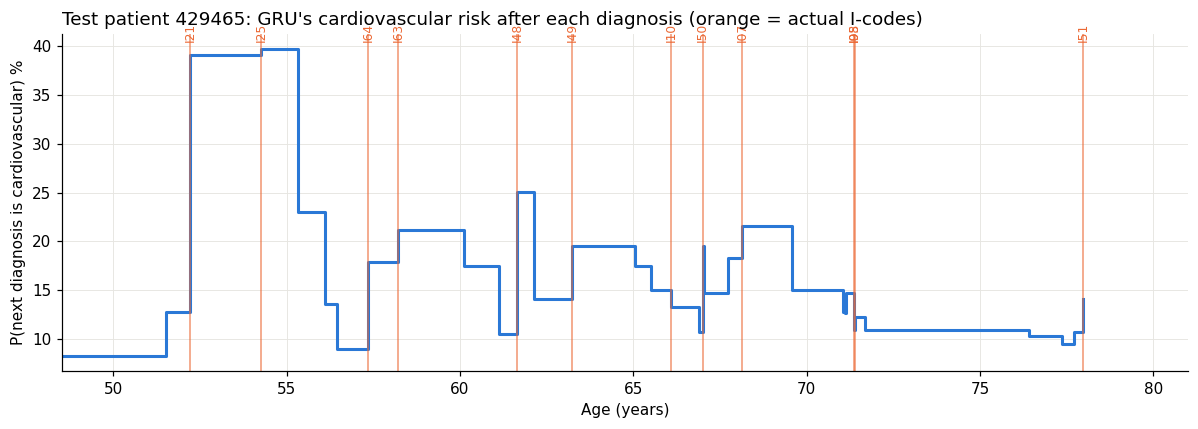

In [71]:
# Plot 15, ek patient ka cardiovascular risk umar ke saath
#Probability that the NEXT diagnosis is cardiovascular (any I-code), after each event.
circulatory = [t for t in known_codes if code_of[t].startswith("I")]
# pick a test patient with several cardiovascular diagnoses (and not too long a history, so the plot is readable)
def n_cardio(p):
    t = seqs["test"][p][0]
    return sum(code_of[x].startswith("I") for x in t[1:]) if len(t) < 35 else 0
pid = max(seqs["test"], key=n_cardio)
tokens, ages = seqs["test"][pid]
g = gru_inputs["test"]
r = g["row_of"][pid]
L = g["lengths"][r]
with torch.no_grad():
    gru_model.eval()
    h = gru_model.hidden_states(torch.tensor(g["codes"][[r], :L], device=device),
                                torch.tensor(g["age"][[r], :L], device=device),
                                torch.tensor(g["gap"][[r], :L], device=device))
    probs = F.softmax(gru_model.output(h[0]), dim=1).cpu().numpy()

risk = []
for j in range(L):
    p = probs[j] * valid
    p[tokens[:j + 1]] = 0
    risk.append(100 * p[circulatory].sum() / p.sum())

fig, ax = plt.subplots(figsize=(11, 4))
ax.step(ages, risk, where="post", color=BLUE, linewidth=2)
for a, t in zip(ages[1:], tokens[1:]):
    if code_of[t].startswith("I"):
        ax.axvline(a, color=ORANGE, linewidth=1, alpha=0.7)
        ax.text(a, max(risk) * 1.02, code_of[t], rotation=90, fontsize=8, color=ORANGE, ha="center", va="bottom")
ax.set_xlim(max(0, ages[1] - 3), 81)                 # zoom in on the part of life with diagnoses
ax.set_xlabel("Age (years)")
ax.set_ylabel("P(next diagnosis is cardiovascular) %")
ax.set_title(f"Test patient {pid}: GRU's cardiovascular risk after each diagnosis (orange = actual I-codes)", loc="left")
plt.tight_layout()
save_fig("model_6_patient_example.png")
plt.show()

In [72]:
main_table.to_csv(os.path.join(OUT_DIR, "results_main.csv"))
auc_table.to_csv(os.path.join(OUT_DIR, "results_key_conditions_auc.csv"))
pd.DataFrame(ece_rows).to_csv(os.path.join(OUT_DIR, "results_calibration_ece.csv"), index=False)
by_freq.to_csv(os.path.join(OUT_DIR, "results_by_frequency.csv"))
torch.save(gru_model.state_dict(), os.path.join(OUT_DIR, "gru_model.pt"))
print("Saved results tables and the trained GRU to", OUT_DIR)

Saved results tables and the trained GRU to /content/outputs
